# 06 -- Harmonization Robustness & Cross-Validation Strategy Comparison

**Corresponds to:** Manuscript Sec.3.4.4 (Confound Control), Tables 3 & 4

This notebook systematically evaluates classification performance across three validation strategies:
1. **Standard 5-Fold** -- random stratified splits
2. **Site-Stratified 5-Fold** -- each fold preserves site proportions
3. **Leave-One-Site-Out (LOSO)** -- train on all but one site, test on held-out site

Each strategy is evaluated **with and without** ComBat harmonization to quantify scanner-effect mitigation.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import class_weight, resample
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
import os, warnings, sys
warnings.filterwarnings('ignore')
np.random.seed(41)

try:
    from neuroCombat import neuroCombat
    COMBAT_AVAILABLE = True
except ImportError:
    COMBAT_AVAILABLE = False
    print("WARNING: neuroCombat not available. Harmonized runs will be skipped.")

DATA_DIR = os.path.join("data")
RESULTS_DIR = os.path.join("results")
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Pipeline Function

In [2]:
def evaluate_config(df, input_features, mode, cv_strategy, use_combat, site_col='scan_site_text'):
    """Run one CV + ComBat configuration and return metrics."""

    if mode == 'patient_vs_control':
        diag_col = 'diag_pvc'
        pos_label = 'Patient'
    else:
        diag_col = 'diag_scz'
        pos_label = 'SCZ'

    task_df = df[df[diag_col] != 'Remove'].copy()
    y = (task_df[diag_col] == pos_label).astype(int).values
    sites = task_df[site_col].astype(str).values

    X_raw = task_df[input_features].values

    # ComBat
    if use_combat and COMBAT_AVAILABLE:
        covars = pd.DataFrame({'batch': sites, 'disease': y})
        try:
            combat_out = neuroCombat(dat=X_raw.T, covars=covars, batch_col='batch', categorical_cols=['disease'])
            X = combat_out['data'].T
        except:
            X = X_raw.copy()
    else:
        X = X_raw.copy()

    df_proc = pd.DataFrame(X, columns=input_features)

    # CV setup
    if cv_strategy == 'Leave-One-Site-Out':
        splitter = LeaveOneGroupOut()
        splits = list(splitter.split(df_proc, y, groups=sites))
    else:
        if cv_strategy == 'Site-Stratified 5-Fold':
            strata = sites + '_' + y.astype(str)
        else:
            strata = y
        splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)
        splits = list(splitter.split(df_proc, strata))

    all_y_true, all_y_pred = [], []

    for train_idx, test_idx in splits:
        X_train_full = df_proc.iloc[train_idx]
        y_train = y[train_idx]
        X_test_full = df_proc.iloc[test_idx]
        y_test = y[test_idx]

        # Nested feature selection
        auc_scores = []
        for feat in input_features:
            try:
                sc = roc_auc_score(y_train, X_train_full[feat])
                auc_scores.append({'feature': feat, 'auc': sc})
            except: pass
        auc_df = pd.DataFrame(auc_scores)
        auc_df['disc'] = np.abs(auc_df['auc'] - 0.5)
        top20 = auc_df.sort_values('disc', ascending=False).head(20)['feature'].tolist()

        X_train = X_train_full[top20].values
        X_test = X_test_full[top20].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # NN
        model = keras.Sequential([
            layers.Input(shape=(X_train_scaled.shape[1],)),
            layers.Dense(64, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy')

        cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        cw_dict = dict(zip(np.unique(y_train), cw))

        early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
        X_t, X_v, y_t, y_v = train_test_split(X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)
        model.fit(X_t, y_t, validation_data=(X_v, y_v), epochs=100, batch_size=32,
                  verbose=0, callbacks=[early_stop], class_weight=cw_dict)

        y_pred = model.predict(X_test_scaled, verbose=0).flatten()
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    # Bootstrap CI
    auc_scores_boot = []
    ap_scores_boot = []
    for _ in range(500):
        idx = resample(np.arange(len(all_y_true)), replace=True)
        if len(np.unique(all_y_true[idx])) < 2: continue
        auc_scores_boot.append(roc_auc_score(all_y_true[idx], all_y_pred[idx]))
        ap_scores_boot.append(average_precision_score(all_y_true[idx], all_y_pred[idx]))

    return {
        'Task': 'Patient vs Control' if mode == 'patient_vs_control' else 'SCZ vs Non-SCZ',
        'CV Strategy': cv_strategy,
        'ComBat': 'Yes' if use_combat else 'No',
        'AUC-ROC': f"{roc_auc_score(all_y_true, all_y_pred):.3f} +/- {np.std(auc_scores_boot):.3f}",
        'Avg Precision': f"{average_precision_score(all_y_true, all_y_pred):.3f} +/- {np.std(ap_scores_boot):.3f}"
    }

## 2. Run Grid for Patient vs Control (Table 3)

In [3]:
df = pd.read_pickle(os.path.join(DATA_DIR, "data_full.pkl"))
input_features = [c for c in df.columns if not c.startswith("harm_") and c not in [
    'XNAT_ID', 'Participant_Type', 'Dataset', 'Participant_Type_2', 'Participant_Type_text',
    'Diagnosis_three_categories_code', 'Diagnosis_three_categories_code_label',
    'Diagnosis_code_detailed', 'Diagnosis_label_detailed', 'Recruitment_location',
    'scan_site_text', 'age_demo', 'sex_code', 'sex_label', 'education_code', 'education_label',
    'sub_handedness_code', 'sub_handedness_label', 'diag_pvc', 'diag_scz',
    'firstepisode_psychosis_date', 'apd_chlor_equiv_CPZ', 'apd_date_equiv_CPZ',
    'lifetime_total_exposure_mg_MEDS', 'lifetime_total_exposure_gr_MEDS',
    'cains_map_total', 'cains_exp_total', 'cains_total_missing_blank',
    'cains_total_mean_with_existing', 'CAINS_total_mean_imputation',
    'panss_totalscore', 'PANSS_marder_neg', 'PANSS_marder_pos',
    'panss_experimental_neg', 'panss_expressive_neg', 'marder_cog_diso',
    'madrs_total', 'ymrs_total', 'PANSS_Positive', 'PANSS_neg_total_with_all_avail_items',
    'PANSS_neg_missing_items_total_blank', 'PANSS_neg_mean_imputed_missing_items',
    'NIH Toolbox Emotional Support RAW', 'NIH Toolbox Instrumental Support RAW',
    'NIH Toolbox Friendship RAW', 'NIH Toolbox Loneliness RAW',
    'NIH Toolbox Perceived Rejection RAW', 'NIH Toolbox Perceived Hostility RAW',
    'NIH Toolbox Emotional Support Tscore', 'NIH Toolbox Instrumental Support Tscore',
    'NIH Toolbox Friendship Tscore', 'NIH Toolbox Loneliness Tscore',
    'NIH Toolbox Perceived Rejection Tscore', 'NIH Toolbox Perceived Hostility Tscore',
    'bnss_asociality_behav', 'bnss_asociality_intexp', 'bnss_total'
]]
input_features = [f for f in input_features if f.startswith(('lh_', 'rh_'))]
print(f"Using {len(input_features)} feature columns")

strategies = ['Standard 5-Fold', 'Site-Stratified 5-Fold', 'Leave-One-Site-Out']
combat_states = [False, True]

print("\n" + "="*70)
print("TABLE 3: PATIENT VS CONTROL -- HARMONIZATION x CV STRATEGY")
print("="*70)

table3_rows = []
for cv in strategies:
    for combat in combat_states:
        if combat and not COMBAT_AVAILABLE:
            continue
        result = evaluate_config(df, input_features, 'patient_vs_control', cv, combat)
        table3_rows.append(result)
        print(f"  {cv:25s} | ComBat: {'Yes' if combat else 'No ':4s} | AUC: {result['AUC-ROC']} | AP: {result['Avg Precision']}")

table3 = pd.DataFrame(table3_rows)
print(f"\n{table3.to_string(index=False)}")
table3.to_csv(os.path.join(RESULTS_DIR, "table3_patient_vs_control_harmonization.csv"), index=False)
print(f"\nSaved to: {RESULTS_DIR}/table3_patient_vs_control_harmonization.csv")

Using 413 feature columns

TABLE 3: PATIENT VS CONTROL -- HARMONIZATION x CV STRATEGY


  Standard 5-Fold           | ComBat: No   | AUC: 1.000 +/- 0.000 | AP: 1.000 +/- 0.000
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Standard 5-Fold           | ComBat: Yes  | AUC: 1.000 +/- 0.000 | AP: 1.000 +/- 0.000


  Site-Stratified 5-Fold    | ComBat: No   | AUC: 1.000 +/- 0.000 | AP: 1.000 +/- 0.000
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Site-Stratified 5-Fold    | ComBat: Yes  | AUC: 1.000 +/- 0.000 | AP: 1.000 +/- 0.000


  Leave-One-Site-Out        | ComBat: No   | AUC: 0.108 +/- 0.013 | AP: 0.078 +/- 0.006
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Leave-One-Site-Out        | ComBat: Yes  | AUC: 1.000 +/- 0.000 | AP: 1.000 +/- 0.000

              Task            CV Strategy ComBat         AUC-ROC   Avg Precision
Patient vs Control        Standard 5-Fold     No 1.000 +/- 0.000 1.000 +/- 0.000
Patient vs Control        Standard 5-Fold    Yes 1.000 +/- 0.000 1.000 +/- 0.000
Patient vs Control Site-Stratified 5-Fold     No 1.000 +/- 0.000 1.000 +/- 0.000
Patient vs Control Site-Stratified 5-Fold    Yes 1.000 +/- 0.000 1.000 +/- 0.000
Patient vs Control     Leave-One-Site-Out     No 0.108 +/- 0.013 0.078 +/- 0.006
Patient vs Control     Leave-One-Site-Out    Yes 1.000 +/- 0.000 1.000 +/- 0.000

Saved to: results/table3_patient_vs_control_harmonization.csv


## 3. Run Grid for SCZ vs Non-SCZ (Table 4)

In [4]:
print("\n" + "="*70)
print("TABLE 4: SCZ VS NON-SCZ -- HARMONIZATION x CV STRATEGY")
print("="*70)

# Use unharmonized features for these runs
input_features_raw = [f for f in input_features]  # Already raw features

table4_rows = []
for cv in strategies:
    for combat in combat_states:
        if combat and not COMBAT_AVAILABLE:
            continue
        result = evaluate_config(df, input_features_raw, 'scz_vs_non_scz', cv, combat)
        table4_rows.append(result)
        print(f"  {cv:25s} | ComBat: {'Yes' if combat else 'No ':4s} | AUC: {result['AUC-ROC']} | AP: {result['Avg Precision']}")

table4 = pd.DataFrame(table4_rows)
print(f"\n{table4.to_string(index=False)}")
table4.to_csv(os.path.join(RESULTS_DIR, "table4_scz_vs_non_scz_harmonization.csv"), index=False)
print(f"\nSaved to: {RESULTS_DIR}/table4_scz_vs_non_scz_harmonization.csv")


TABLE 4: SCZ VS NON-SCZ -- HARMONIZATION x CV STRATEGY


  Standard 5-Fold           | ComBat: No   | AUC: 0.640 +/- 0.043 | AP: 0.737 +/- 0.046
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Standard 5-Fold           | ComBat: Yes  | AUC: 0.652 +/- 0.044 | AP: 0.745 +/- 0.045


  Site-Stratified 5-Fold    | ComBat: No   | AUC: 0.582 +/- 0.047 | AP: 0.680 +/- 0.050
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Site-Stratified 5-Fold    | ComBat: Yes  | AUC: 0.516 +/- 0.047 | AP: 0.640 +/- 0.052


  Leave-One-Site-Out        | ComBat: No   | AUC: 0.644 +/- 0.041 | AP: 0.740 +/- 0.042
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


  Leave-One-Site-Out        | ComBat: Yes  | AUC: 0.615 +/- 0.045 | AP: 0.668 +/- 0.052

          Task            CV Strategy ComBat         AUC-ROC   Avg Precision
SCZ vs Non-SCZ        Standard 5-Fold     No 0.640 +/- 0.043 0.737 +/- 0.046
SCZ vs Non-SCZ        Standard 5-Fold    Yes 0.652 +/- 0.044 0.745 +/- 0.045
SCZ vs Non-SCZ Site-Stratified 5-Fold     No 0.582 +/- 0.047 0.680 +/- 0.050
SCZ vs Non-SCZ Site-Stratified 5-Fold    Yes 0.516 +/- 0.047 0.640 +/- 0.052
SCZ vs Non-SCZ     Leave-One-Site-Out     No 0.644 +/- 0.041 0.740 +/- 0.042
SCZ vs Non-SCZ     Leave-One-Site-Out    Yes 0.615 +/- 0.045 0.668 +/- 0.052

Saved to: results/table4_scz_vs_non_scz_harmonization.csv


## 4. Summary Visualization

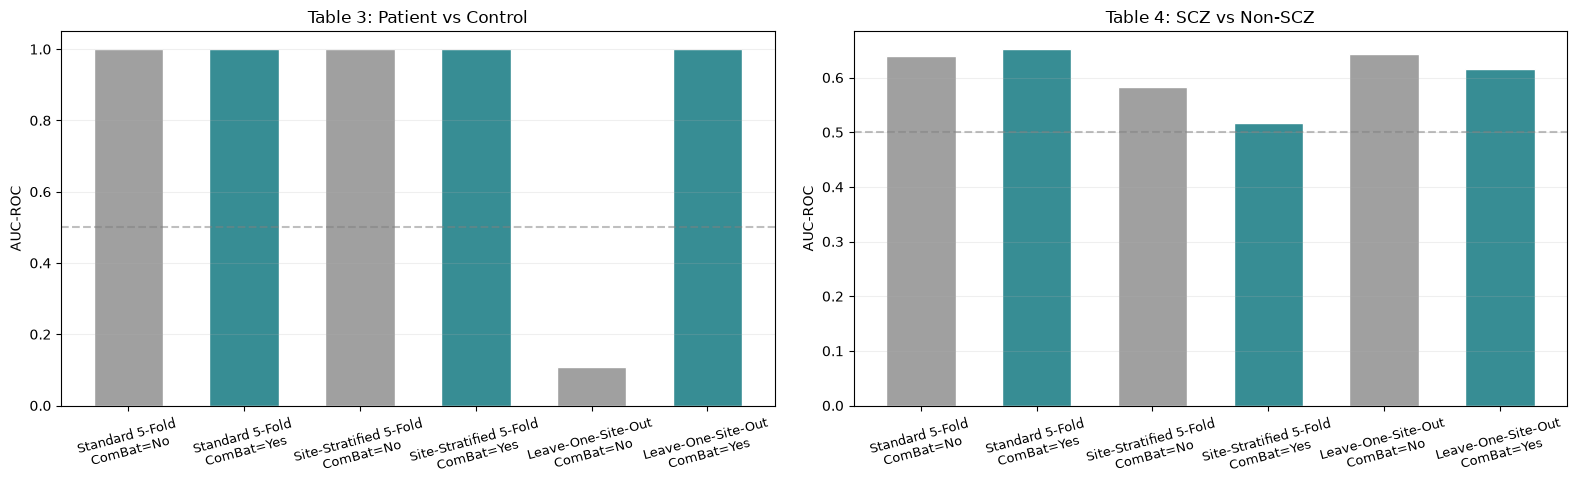


✓ Harmonization robustness analysis complete.

Results saved to: results/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tbl, title in zip(axes, [table3, table4], ['Patient vs Control', 'SCZ vs Non-SCZ']):
    x = range(len(tbl))
    auc_vals = [float(r['AUC-ROC'].split('+/-')[0]) for _, r in tbl.iterrows()]
    colors = ['#378d94' if 'Yes' in r['ComBat'] else '#a0a0a0' for _, r in tbl.iterrows()]
    ax.bar(x, auc_vals, color=colors, edgecolor='w', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['CV Strategy']}\nComBat={r['ComBat']}" for _, r in tbl.iterrows()],
                       fontsize=9, rotation=15)
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'Table {3 if "Patient" in title else 4}: {title}')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "harmonization_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Harmonization robustness analysis complete.")
print(f"\nResults saved to: {RESULTS_DIR}/")